<a href="https://colab.research.google.com/github/patriciaruizpaz/clinical-deterioration-intelligence/blob/main/notebooks/03_multivariado_bayesiana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# CELDA 1 — Montar Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================
# CELDA 2 — Configurar git y clonar el repo (limpio, sin duplicar carpetas)
# ============================================
from getpass import getpass
import os

TOKEN = getpass("Pegá tu token de GitHub: ")

!git config --global user.email "patricia.megi@gmail.com"
!git config --global user.name "patriciaruizpaz"

if os.path.exists('/content/clinical-deterioration-intelligence'):
    !rm -rf /content/clinical-deterioration-intelligence

%cd /content
!git clone https://{TOKEN}@github.com/patriciaruizpaz/clinical-deterioration-intelligence.git
%cd clinical-deterioration-intelligence
!pwd

Pegá tu token de GitHub: ··········
/content
Cloning into 'clinical-deterioration-intelligence'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 67 (delta 25), reused 44 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 13.76 MiB | 15.50 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/clinical-deterioration-intelligence
/content/clinical-deterioration-intelligence


In [3]:
# ============================================
# CELDA 3 — Fase 4: reproducibilidad y setup técnico
# ============================================
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
random.seed(42)
sns.set_theme(style="whitegrid")

print("Setup completo ✅")

Setup completo ✅


In [4]:
# ============================================
# CELDA 4 — Leer el dataset limpio (Fase 9 en adelante)
# ============================================
ruta_processed = '/content/drive/MyDrive/Portfolio_Datos/clinical-deterioration-intelligence/data/processed/'

panel = pd.read_csv(ruta_processed + 'panel_con_target.csv')

print(panel.shape)
print(panel['deterioration_next_12h'].value_counts(normalize=True).round(4) * 100)

(416635, 28)
deterioration_next_12h
0    94.61
1     5.39
Name: proportion, dtype: float64


## Fase 12 — Control de calidad de resultados (checkpoint breve)

Antes de avanzar a las Preguntas 3 y 4, se confirma consistencia entre lo resuelto
en `02_analisis_estadistico.ipynb`:
- Pregunta 1 (Mann-Whitney): lactato con el mayor tamaño de efecto (r=0.547).
- Pregunta 2 (regresión logística): lactato con el odds ratio más alto (1.43),
  el predictor más fuerte del modelo.

Ambos análisis, con métodos distintos, coinciden en la misma variable como
señal principal — buena señal de robustez del hallazgo, no es un artefacto
de un solo método.

## Fase 13 — Análisis multivariado (Preguntas 3 y 4)

**Pregunta 3 (PCA):** ¿se pueden resumir las ~12 variables horarias de vitales
y labs en menos componentes que representen el "estado clínico general"?

**Pregunta 4 (Clustering):** ¿existen perfiles clínicos naturales de pacientes
según su trayectoria en las primeras 24h? (requiere cambio de granularidad,
ver nota de la Fase 3 — de hora a paciente).

In [6]:
# Fase 13 — Pregunta 3, Paso 1: estandarizar variables para PCA
from sklearn.preprocessing import StandardScaler

vars_pca = ['heart_rate', 'respiratory_rate', 'spo2_pct', 'temperature_c',
            'systolic_bp', 'diastolic_bp', 'lactate', 'wbc_count',
            'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score']

X_pca_raw = panel[vars_pca].dropna()

scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca_raw)

print("Forma de los datos estandarizados:", X_pca_scaled.shape)
print("Media por columna (debería ser ~0):", X_pca_scaled.mean(axis=0).round(2))
print("Desvío por columna (debería ser ~1):", X_pca_scaled.std(axis=0).round(2))

Forma de los datos estandarizados: (416635, 12)
Media por columna (debería ser ~0): [ 0. -0. -0.  0. -0. -0. -0.  0.  0.  0.  0. -0.]
Desvío por columna (debería ser ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [7]:
# Fase 13 — Pregunta 3, Paso 2: PCA completo (todos los componentes posibles)
from sklearn.decomposition import PCA

pca_completo = PCA()
pca_completo.fit(X_pca_scaled)

varianza_explicada = pca_completo.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

tabla_varianza = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(varianza_explicada))],
    'Varianza explicada (%)': (varianza_explicada * 100).round(2),
    'Varianza acumulada (%)': (varianza_acumulada * 100).round(2)
})
print(tabla_varianza)

   Componente  Varianza explicada (%)  Varianza acumulada (%)
0         PC1                   64.74                   64.74
1         PC2                    5.59                   70.33
2         PC3                    5.36                   75.69
3         PC4                    4.68                   80.37
4         PC5                    4.47                   84.84
5         PC6                    3.97                   88.81
6         PC7                    3.28                   92.09
7         PC8                    2.65                   94.75
8         PC9                    1.85                   96.60
9        PC10                    1.46                   98.05
10       PC11                    1.07                   99.12
11       PC12                    0.88                  100.00


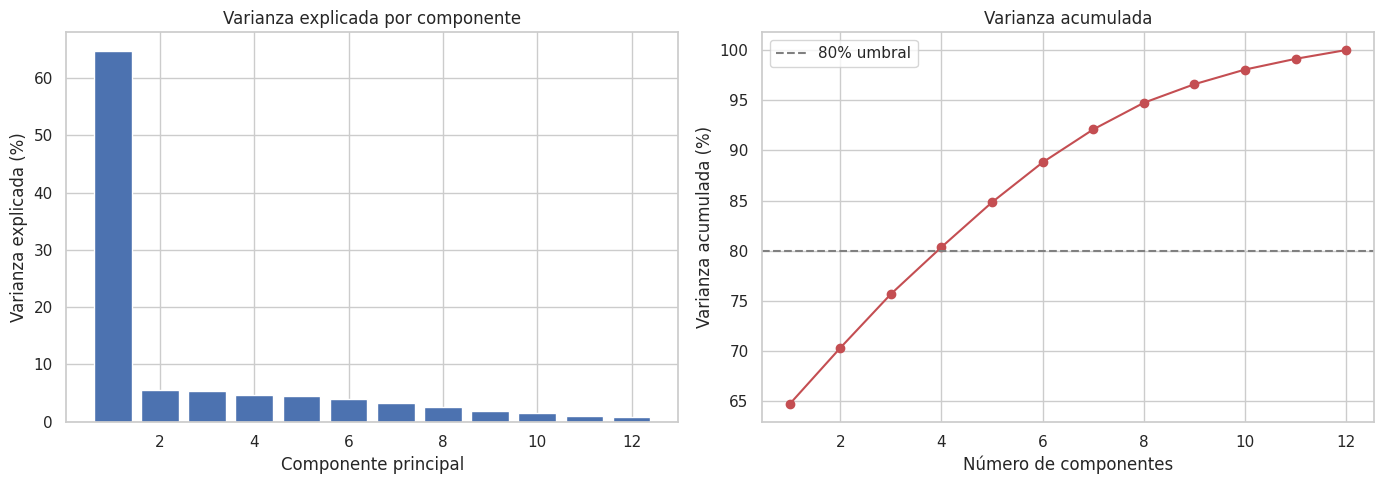

In [8]:
# Fase 13 — Pregunta 3, Paso 3: scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(varianza_explicada)+1), varianza_explicada * 100, color='#4C72B0')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza explicada por componente')

axes[1].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada * 100, marker='o', color='#C44E52')
axes[1].axhline(y=80, color='gray', linestyle='--', label='80% umbral')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada')
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_varianza.png', dpi=200, bbox_inches='tight')
plt.show()

In [9]:
# Fase 13 — Pregunta 3, Paso 4: loadings de los primeros 4 componentes
pca_4 = PCA(n_components=4)
componentes_pca = pca_4.fit_transform(X_pca_scaled)

loadings = pd.DataFrame(
    pca_4.components_.T,
    columns=['PC1', 'PC2', 'PC3', 'PC4'],
    index=vars_pca
)
print(loadings.round(3))

                     PC1    PC2    PC3    PC4
heart_rate         0.293 -0.053 -0.019  0.102
respiratory_rate   0.278  0.012 -0.085  0.092
spo2_pct          -0.325 -0.026 -0.017 -0.027
temperature_c      0.256 -0.220  0.361  0.565
systolic_bp       -0.242 -0.182  0.597  0.143
diastolic_bp      -0.244 -0.097  0.579 -0.257
lactate            0.336  0.108  0.107 -0.064
wbc_count          0.317  0.034  0.173 -0.020
creatinine         0.330  0.010  0.081  0.069
crp_level          0.332 -0.017  0.111  0.065
hemoglobin        -0.228  0.794  0.079  0.520
sepsis_risk_score  0.251  0.511  0.323 -0.540


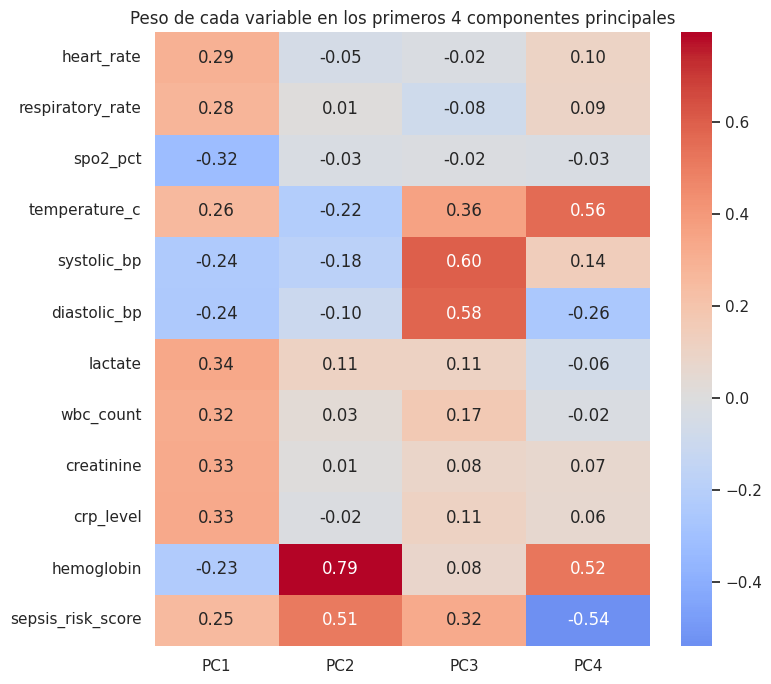

In [10]:
# Fase 13 — Pregunta 3, Paso 5: heatmap de loadings
plt.figure(figsize=(8, 7))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Peso de cada variable en los primeros 4 componentes principales')
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=200, bbox_inches='tight')
plt.show()

## Fase 13 — Pregunta 3: Conclusión (PCA)

**Resultado:** las 12 variables horarias de vitales y laboratorio se resumen
en 4 componentes principales, que explican el 80.4% de la varianza total.

**Interpretación clínica de cada componente:**
- **PC1 — Gravedad clínica general (64.7% de la varianza):** combina
  taquicardia, taquipnea, hipoxemia y marcadores inflamatorios (lactato,
  creatinina, CRP, WBC) en una sola dimensión. Confirma matemáticamente el
  Hallazgo 2 de la Fase 8 (multicolinealidad entre labs) — es la misma señal
  oculta de "gravedad general" que ya se había detectado en las correlaciones.
- **PC2 — Capacidad de oxigenación (5.6%):** dominado por hemoglobina,
  relativamente independiente de la gravedad general.
- **PC3 — Estado hemodinámico (5.4%):** dominado por presión sistólica y
  diastólica.
- **PC4 (4.7%):** componente mixto, de interpretación menos clara —
  consistente con que 4 sea un buen punto de corte.

**Implicación para la Pregunta 4 (clustering):** dado que PC1 concentra la
gran mayoría de la varianza y representa "gravedad general", es esperable
que el clustering separe pacientes principalmente por ese eje.

In [11]:
# Fase 13 — Pregunta 4, Paso 1: cambio de granularidad — de hora a paciente (primeras 24h)
panel_24h = panel[panel['hour_from_admission'] < 24]

agregado_paciente = panel_24h.groupby('patient_id').agg(
    heart_rate_mean=('heart_rate', 'mean'),
    respiratory_rate_mean=('respiratory_rate', 'mean'),
    spo2_pct_mean=('spo2_pct', 'mean'),
    spo2_pct_min=('spo2_pct', 'min'),
    temperature_c_mean=('temperature_c', 'mean'),
    systolic_bp_mean=('systolic_bp', 'mean'),
    lactate_mean=('lactate', 'mean'),
    lactate_max=('lactate', 'max'),
    wbc_count_mean=('wbc_count', 'mean'),
    creatinine_mean=('creatinine', 'mean'),
    crp_level_mean=('crp_level', 'mean'),
    hemoglobin_mean=('hemoglobin', 'mean'),
    sepsis_risk_score_mean=('sepsis_risk_score', 'mean'),
).reset_index()

print(agregado_paciente.shape)
agregado_paciente.head()

(10000, 14)


,patient_id,heart_rate_mean,respiratory_rate_mean,spo2_pct_mean,spo2_pct_min,temperature_c_mean,systolic_bp_mean,lactate_mean,lactate_max,wbc_count_mean,creatinine_mean,crp_level_mean,hemoglobin_mean,sepsis_risk_score_mean
0,1,72.707647,14.442353,94.630000,93.55,37.223529,108.320588,1.356471,1.66,6.287647,1.235294,13.023529,13.520000,0.401065
1,2,80.673333,23.987917,94.140417,86.77,37.186667,91.601667,2.537500,5.00,8.195833,1.450000,38.507500,11.858333,0.564721
2,3,81.935417,24.064167,93.385833,91.86,36.820833,128.251667,2.159167,2.63,11.783333,0.848750,27.892500,13.122917,0.584792
3,4,77.475417,14.158333,96.186250,94.41,36.827083,104.147500,1.136250,1.36,6.899167,1.149167,42.744583,13.552500,0.383850
4,5,83.253182,14.988182,91.105000,80.61,37.518182,132.644091,1.687727,3.90,10.678636,1.082273,20.919091,11.466364,0.493236


In [12]:
# Fase 13 — Pregunta 4, Paso 2: estandarizar features de paciente
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

vars_cluster = [c for c in agregado_paciente.columns if c != 'patient_id']
X_cluster_raw = agregado_paciente[vars_cluster]

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster_raw)

print("Forma:", X_cluster_scaled.shape)

Forma: (10000, 13)


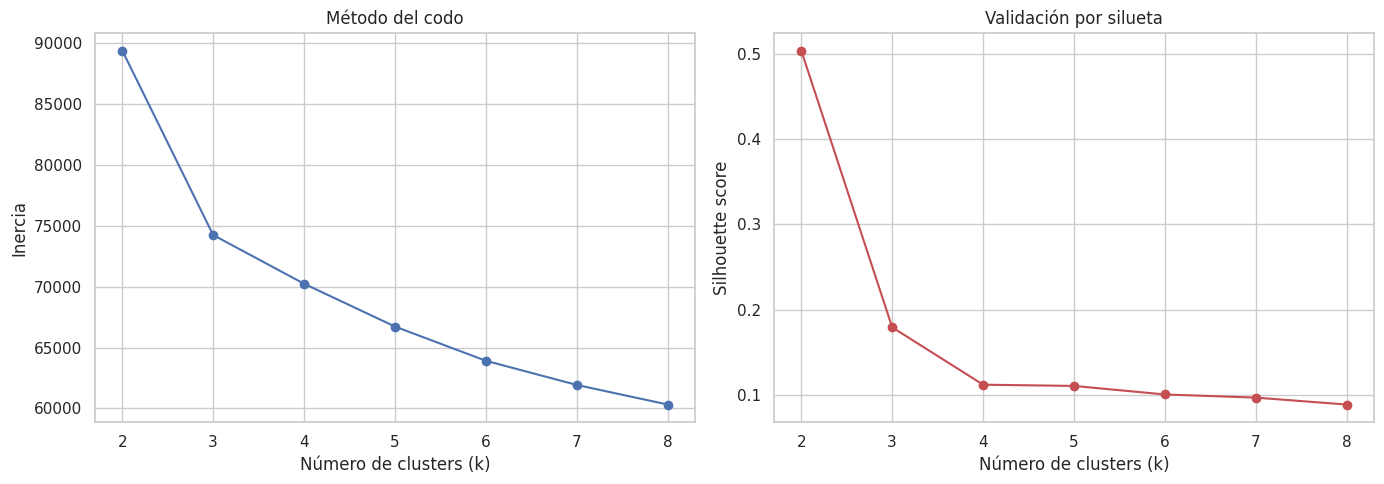

k=2: silhouette=0.5039
k=3: silhouette=0.1794
k=4: silhouette=0.1121
k=5: silhouette=0.1106
k=6: silhouette=0.1006
k=7: silhouette=0.0969
k=8: silhouette=0.0888


In [13]:
# Fase 13 — Pregunta 4, Paso 3: método del codo + silueta, para 2 a 8 clusters
inercias = []
siluetas = []
rango_k = range(2, 9)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rango_k, inercias, marker='o', color='#4C72B0')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo')

axes[1].plot(rango_k, siluetas, marker='o', color='#C44E52')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Validación por silueta')

plt.tight_layout()
plt.savefig('clustering_validacion.png', dpi=200, bbox_inches='tight')
plt.show()

for k, s in zip(rango_k, siluetas):
    print(f"k={k}: silhouette={s:.4f}")

In [14]:
# Fase 13 — Pregunta 4, Paso 4: k-means final (k=2) y asignación de clusters
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
agregado_paciente['cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

print(agregado_paciente['cluster'].value_counts())
print()

# Caracterización: medias de cada variable por cluster
caracterizacion = agregado_paciente.groupby('cluster')[vars_cluster].mean().round(2)
print(caracterizacion.T)

cluster
0    9223
1     777
Name: count, dtype: int64

cluster                      0       1
heart_rate_mean          84.64  102.57
respiratory_rate_mean    18.68   24.28
spo2_pct_mean            95.19   88.67
spo2_pct_min             93.40   79.05
temperature_c_mean       36.88   37.16
systolic_bp_mean        116.48  101.21
lactate_mean              1.55    3.39
lactate_max               1.88    6.11
wbc_count_mean            8.21   11.69
creatinine_mean           1.15    1.78
crp_level_mean           24.65   56.56
hemoglobin_mean          13.47   12.82
sepsis_risk_score_mean    0.44    0.71


In [15]:
# Fase 13 — Pregunta 4, Paso 5: ¿los clusters se relacionan con el deterioro real?
deterioro_por_paciente = panel.groupby('patient_id')['deterioration_next_12h'].max().reset_index()
deterioro_por_paciente.columns = ['patient_id', 'deterioro_alguna_vez_24h']

agregado_con_deterioro = agregado_paciente.merge(deterioro_por_paciente, on='patient_id')

tasa_deterioro_por_cluster = agregado_con_deterioro.groupby('cluster')['deterioro_alguna_vez_24h'].mean() * 100
print(tasa_deterioro_por_cluster.round(2))

cluster
0    12.70
1    98.33
Name: deterioro_alguna_vez_24h, dtype: float64
